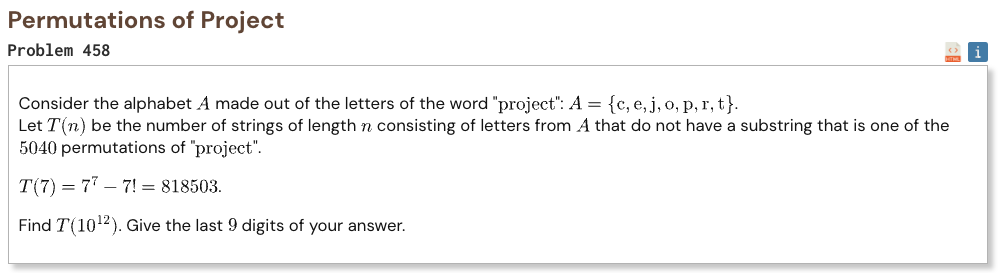

## Initial approach

-   the alphabet has 7 different letters from the word project
-   a forbidden substring appears whenever 7 consecutive letters are all different
-   keep track of the length of the current suffix whose letters are all distinct
-   if the next letter is new, this suffix grows by one
-   if the next letter repeats one of the suffix letters, the new suffix length depends on where that letter last appeared
-   state 7 is never allowed because it would create a permutation of project
-   build a small transition matrix for states 0 through 6
-   use fast matrix exponentiation to jump directly to length 10 to the power 12 and keep only the last 9 digits

In [1]:
%%time

N = 10**12
MOD = 10**9
SIZE = 7

def matrix_multiply(a, b):
    result = [[0] * SIZE for _ in range(SIZE)]

    for i in range(SIZE):
        for k in range(SIZE):
            if a[i][k] == 0:
                continue

            for j in range(SIZE):
                result[i][j] += a[i][k] * b[k][j]
                result[i][j] %= MOD

    return result

def matrix_power(matrix, exponent):
    result = [
        [1 if i == j else 0 for j in range(SIZE)]
        for i in range(SIZE)
    ]

    while exponent > 0:
        if exponent % 2 == 1:
            result = matrix_multiply(result, matrix)

        matrix = matrix_multiply(matrix, matrix)
        exponent //= 2

    return result

transition = [[0] * SIZE for _ in range(SIZE)]

transition[1][0] = 7

for length in range(1, 7):
    for new_length in range(1, length + 1):
        transition[new_length][length] += 1

    if length < 6:
        transition[length + 1][length] += 7 - length

powered = matrix_power(transition, N)

result = sum(powered[state][0] for state in range(SIZE)) % MOD

print("Result:", result)

Result: 423341841
CPU times: user 1.7 ms, sys: 52 μs, total: 1.75 ms
Wall time: 1.76 ms
